In [53]:
import math
import matplotlib.pyplot as plt
import numpy as np
import random
%matplotlib inline

In [54]:
class Value:
    def __init__(self, data, _children = (), _op="", label=""):
        self.data = data
        self.grad = 0.0
        self._prev = set(_children)
        self.back = lambda: None
        self._op = _op
        self.label = label
    def __repr__(self):
        return f"Value(data) = {self.data}"
    def __add__(self, n):
        n = n if isinstance(n, Value) else Value(n)
        o = Value(self.data + n.data, (self, n), "+")
        def backward():
            self.grad += o.grad * 1.0
            n.grad += o.grad * 1.0
        o.back = backward
        return o
    def __radd__(self, n):
        return self + n
    def __mul__(self, n):
        n = n if isinstance(n, Value) else Value(n)
        o = Value(self.data * n.data, (self, n), "*")
        def backward():
            self.grad += o.grad * n.data
            n.grad += o.grad * self.data
        o.back = backward
        return o
    def __pow__(self, n):
        o = Value(self.data ** n, (self, ), "pow")
        def backward():
            self.grad += n*(self.data**(n-1))*o.grad
        o.back = backward
        return o
    def tanh(self):
        o = Value(math.tanh(self.data), (self, ), "tanh")
        def backward():
            self.grad += o.grad * (1 / math.cosh(self.data)**2)
        o.back = backward
        return o
    def __rmul__(self, n):
        return self * n
    def __truediv__(self, n):
        return self * n**-1
    def __neg__(self):
        return self * -1;
    def __sub__(self, n):
        return self + -n
    def __rsub__(self, n):
        return -self + n
    def backward(self):
        visited = set()
        topo = []
        self.grad = 1.0
        def build_topo(a):
            if(a not in visited):
                visited.add(a)
                for child in a._prev:
                    build_topo(child)
                topo.append(a)
        build_topo(self)
        for item in reversed(topo):
            item.back()       

In [55]:
from graphviz import Digraph

def trace(root):
    # builds a set of all nodes and edges in a graph
    nodes, edges = set(), set()

    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)

    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})  # LR = left to right

    nodes, edges = trace(root)

    for n in nodes:
        uid = str(id(n))

        # for any Value in the graph, create a rectangular ('record') node for it
        dot.node(
            name=uid,
            label="{data = %.4f | var = %s | grad = %.4f}" % (n.data, n.label, n.grad) ,
            shape='record'
        )
        if n._op:
            # if this Value is a result of some operation, create an op node for it
            dot.node(name=uid + n._op, label=n._op)

            # and connect this node to it
            dot.edge(uid + n._op, uid)

    for n1, n2 in edges:
        # connect n1 to the op node of n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot

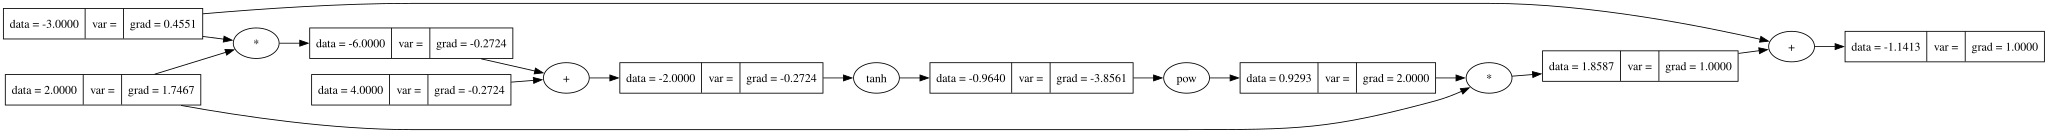

In [56]:
a = Value(2.0)
b = Value(-3.0)
c = Value(4.0)

d = a * b
e = d + c
f = e.tanh()
g = f ** 2
h = g * a
out = h + b

out.backward()

draw_dot(out)

In [57]:
def forward_pass(a, b, c, d):
    x1 = a * b
    x2 = c * d
    
    x3 = x1 + x2
    x4 = x3 * a
    
    x5 = x4 + b
    x6 = x5.tanh()
    
    x7 = x6 ** 2
    x8 = x7 * c
    
    x9 = x8 + x2
    x10 = x9 / a
    
    x11 = x10.tanh()
    out = x11 + x6
    return out

a = Value(2.0)
b = Value(-1.5)
c = Value(3.0)
d = Value(0.5)
l = [a, b, c, d]
out = forward_pass(a, b, c, d)

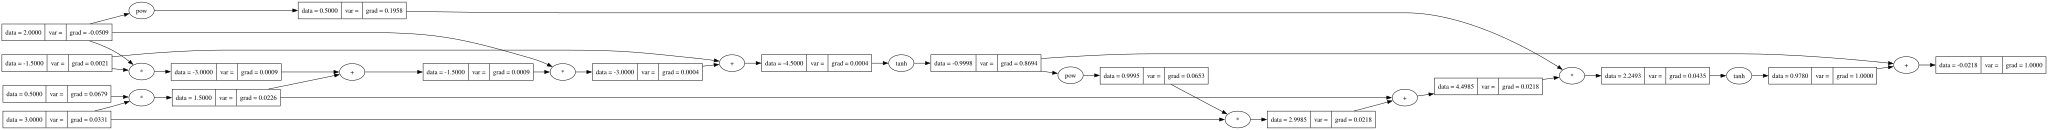

In [58]:
out.backward()

draw_dot(out)

In [59]:
# the same above expression calculated using finite differences 

In [60]:
eps = 1e-6

def central_diff(a):
    a1 = Value(a.data + eps)
    a2 = Value(a.data - eps)
    out_plus = forward_pass(a1, b, c, d).data
    out_minus = forward_pass(a2, b, c, d).data
    finite_da = (out_plus - out_minus) / (2 * eps)
    return finite_da
print("backprop da (from engine) =", a.grad)
print("finite da (central difference)   =", central_diff(a))
print("the difference is very small")

#Similarly you can try out for b, c and d variables also

backprop da (from engine) = -0.050883673686819356
finite da (central difference)   = -0.05088367371897107
the difference is very small


In [61]:
class Neuron:
    def __init__(self, n):
        self.w = [Value(random.uniform(-1, 1)) for w in range(n)]
        self.b = Value(random.uniform(-1, 1))
    def __call__(self, x):
        o = sum(wi*xi for wi, xi in zip(self.w, x)) + self.b
        return o.tanh()
    def params(self):
        return self.w + [self.b]
        
class Layer:
    def __init__(self, nin, no):
        self.layer = [Neuron(nin) for _ in range(no)]
    def __call__(self, x):
        o = [n(x) for n in self.layer]
        return o
    def params(self):
        return [i for neu in self.layer for i in neu.params()]

class MLP:
    def __init__(self, nin, layers):
        self.sz = [nin] + layers
        self.layers = [Layer(self.sz[i], self.sz[i+1]) for i in range(len(self.sz)-1)]
    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x
    def params(self):
        return [neu for layer in self.layers for neu in layer.params()]

In [62]:
n1 = MLP(3, [4,4,1])

In [71]:
xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0]
]
ys = [1.0, -1.0, -0.69, 0.4]  # desired outputs
ypred = [n1(x)[0] for x in xs]

ypred

[Value(data) = 0.9655708012811453,
 Value(data) = -0.9930468513642222,
 Value(data) = -0.6894735552637397,
 Value(data) = 0.4012082199640533]

In [72]:
for i in range(100):
    ypred = [n1(x)[0] for x in xs]
    loss = sum([(yac - yp)**2 for yac, yp in zip(ys, ypred)])
    for p in n1.params():
        p.grad = 0.0
    loss.backward()
    
    for p in n1.params():
        p.data += -0.05*p.grad
ypred

[Value(data) = 0.9691880801962743,
 Value(data) = -0.9936646893088057,
 Value(data) = -0.6895739482059274,
 Value(data) = 0.40094506904260246]